# TESSERA 1B-M VAE-latent variant shortlist

**Goal**: compare the new VAE latents built on TESSERA v2 **1B-M** embeddings
(8 variants: crop {64,128} x latent dim {16,32,64} x aux {on,off}, for embedding
years **2017** and **2024**) against the **previous default** (old TESSERA v1,
`vae_lat16` +mTPI) and the no-TESSERA references — to shortlist which variant to
roll out to the remaining regions.

All runs share the paper config (direct concat, +mTPI, with elevation, no static
fields, wd=1e-4) and differ ONLY in the latents file. Folders:

| axis | where it lives |
|---|---|
| region (EU / East Asia) + year (2017/2024) | experiment folder `snapshot_14y_<region>_tessera_1B-M_<year>` |
| crop / lat dim / aux | experiment name inside the folder |

**Re-run top to bottom any time** — cells are robust to partially-finished sweeps
(pending runs simply show as missing seeds).

Caveats to keep in mind when reading:

- **Station sets**: new runs use old-patch-filter ∩ new-latent-valid. vs the old
  default runs: EU −10/+1 stations (held-out 1758 → 1755), EA +1 — negligible but
  not zero. 2017 vs 2024 sets also differ by ≤10 stations.
- `p128_2024_crop128_lat32_auxoff` VAE was still training at sweep launch — its
  2024 runs lag the rest (auto-picked-up once submitted).
- Wind point MAE is MAE@median (truncated-normal convention); t2m is mean-based
  Gaussian MAE. The `point_mae` / `point_rmse` canonical columns handle this.
  NLL / CRPS are proper scoring rules, comparable across heads.

> **Phase 2 (2026-07-20)**: after the EU/EA round eliminated crop128 and lat64, the crop64 shortlist (lat {16,32} x aux {on,off}, both years) was rolled out to US / Australia / Southern Africa — 144 jobs. The skill tables aggregate over every complete (region x target) cell; `n_cells` shows how many each candidate has (10 = all regions).

In [1]:
# ---- Setup: constants + load ----------------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import _helpers as H

pd.set_option("display.width", 200)

SEEDS = (42, 123, 456)
REGIONS = ["europe", "east_asia", "us", "australia", "southern_africa"]
YEARS = [2017, 2024]
TARGETS = ["t2m", "wind"]

# (region, year) -> new sweep folder
FOLDERS_NEW = {
    ("europe", 2017):    "snapshot_14y_eu_tessera_1B-M_2017",
    ("europe", 2024):    "snapshot_14y_eu_tessera_1B-M_2024",
    ("east_asia", 2017): "snapshot_14y_east_asia_tessera_1B-M_2017",
    ("east_asia", 2024): "snapshot_14y_east_asia_tessera_1B-M_2024",
    # Phase-2 rollout: crop64 shortlist only (lat {16,32} x aux {on,off}).
    ("us", 2017):              "snapshot_14y_us_tessera_1B-M_2017",
    ("us", 2024):              "snapshot_14y_us_tessera_1B-M_2024",
    ("australia", 2017):       "snapshot_14y_australia_tessera_1B-M_2017",
    ("australia", 2024):       "snapshot_14y_australia_tessera_1B-M_2024",
    ("southern_africa", 2017): "snapshot_14y_southern_africa_tessera_1B-M_2017",
    ("southern_africa", 2024): "snapshot_14y_southern_africa_tessera_1B-M_2024",
}
# region -> folder holding the previous default + references
FOLDERS_OLD = {"europe": "snapshot_14y_eu", "east_asia": "snapshot_14y_east_asia",
               "us": "snapshot_14y_us", "australia": "snapshot_14y_australia",
               "southern_africa": "snapshot_14y_southern_africa"}

# Reference experiments (paper +mTPI table): previous default TESSERA v1
# lat16, its trained no-TESSERA twin, and the non-trained references.
REF_EXPS = {
    "t2m": {
        "old default (v1 lat16)": "t2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
        "no-TESSERA ConvCNP":     "t2m_snap_bilinear_baseline_mtpi_wd",
        "ERA5-interp":            "t2m_snap_era5_interp_baseline",
        "persistence":            "t2m_snap_persistence_baseline",
    },
    "wind": {
        "old default (v1 lat16)": "wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
        "no-TESSERA ConvCNP":     "wind_truncnormal_snap_bilinear_baseline_mtpi_wd",
        "ERA5-interp":            "wind_snap_era5_interp_baseline",
        "persistence":            "wind_snap_persistence_baseline",
    },
}

# Display order of the 8 swept variants (crop, then lat, then aux).
VARIANT_ORDER = [
    "crop64_lat16_auxoff",  "crop64_lat16_auxon",
    "crop64_lat32_auxoff",  "crop64_lat32_auxon",
    "crop128_lat16_auxoff",
    "crop128_lat32_auxoff",
    "crop128_lat64_auxoff", "crop128_lat64_auxon",
]

_VAR_RE = re.compile(r"crop(?P<crop>\d+)_lat(?P<lat>\d+)_aux(?P<aux>on|off)")

def parse_variant(exp_name):
    """Extract (variant_key, crop, lat, aux, target) from a sweep entry name."""
    m = _VAR_RE.search(exp_name)
    if m is None:
        return None
    target = "t2m" if exp_name.startswith("t2m") else "wind"
    return dict(
        variant=f"crop{m['crop']}_lat{m['lat']}_aux{m['aux']}",
        crop=int(m["crop"]), lat=int(m["lat"]), aux=m["aux"], target=target,
    )

# ---- Load new-sweep folders ----
new_frames = []
for (region, year), folder in FOLDERS_NEW.items():
    d = H.load_folder_results(folder, seeds=SEEDS)
    if d.empty:
        continue
    d["region"], d["year"] = region, year
    new_frames.append(d)
df_new = pd.concat(new_frames, ignore_index=True) if new_frames else pd.DataFrame()
if not df_new.empty:
    axes = df_new["experiment"].apply(parse_variant)
    for k in ("variant", "crop", "lat", "aux", "target"):
        df_new[k] = axes.apply(lambda a: a[k] if a else None)

# ---- Load reference folders (previous default + baselines) ----
old_frames = []
for region, folder in FOLDERS_OLD.items():
    d = H.load_folder_results(folder, seeds=SEEDS)
    if d.empty:
        continue
    d["region"] = region
    old_frames.append(d)
df_old = pd.concat(old_frames, ignore_index=True) if old_frames else pd.DataFrame()
if not df_old.empty:
    keep = {n: (t, lbl) for t, d in REF_EXPS.items() for lbl, n in d.items()}
    df_old = df_old[df_old["experiment"].isin(keep)].copy()
    df_old["target"] = df_old["experiment"].map(lambda n: keep[n][0])
    df_old["ref_label"] = df_old["experiment"].map(lambda n: keep[n][1])

print(f"new-sweep rows loaded: {len(df_new)}   reference rows loaded: {len(df_old)}")

new-sweep rows loaded: 324   reference rows loaded: 120


In [2]:
# ---- Completeness: which runs have finished? -------------------------------
# Expected: 8 variants x 2 targets x 3 seeds per folder (the pending 2024
# crop128_lat32_auxoff VAE shows up here as missing until its jobs run).
rows = []
for (region, year), folder in FOLDERS_NEW.items():
    sub = df_new[(df_new.get("region") == region) & (df_new.get("year") == year)] \
          if not df_new.empty else pd.DataFrame()
    for v in VARIANT_ORDER:
        cell = {}
        for t in TARGETS:
            n = 0 if sub.empty else int(((sub["variant"] == v) & (sub["target"] == t)).sum())
            cell[t] = n
        rows.append({"folder": folder, "variant": v,
                     "t2m": f"{cell['t2m']}/3", "wind": f"{cell['wind']}/3",
                     "done": cell["t2m"] + cell["wind"]})
comp = pd.DataFrame(rows)
total_done = int(comp["done"].sum())
print(f"finished runs: {total_done}. Gaps are intentional: crop128_lat32_auxoff-2024 "
      f"(EU/EA) was cancelled after crop128 was eliminated, and US/AUS/SA run only "
      f"the crop64 shortlist (phase 2).")
display(comp.pivot(index="variant", columns="folder", values="t2m")
            .reindex(VARIANT_ORDER).rename_axis(None, axis=1))
display(comp.pivot(index="variant", columns="folder", values="wind")
            .reindex(VARIANT_ORDER).rename_axis(None, axis=1))

finished runs: 324. Gaps are intentional: crop128_lat32_auxoff-2024 (EU/EA) was cancelled after crop128 was eliminated, and US/AUS/SA run only the crop64 shortlist (phase 2).


,snapshot_14y_australia_tessera_1B-M_2017,snapshot_14y_australia_tessera_1B-M_2024,snapshot_14y_east_asia_tessera_1B-M_2017,snapshot_14y_east_asia_tessera_1B-M_2024,snapshot_14y_eu_tessera_1B-M_2017,snapshot_14y_eu_tessera_1B-M_2024,snapshot_14y_southern_africa_tessera_1B-M_2017,snapshot_14y_southern_africa_tessera_1B-M_2024,snapshot_14y_us_tessera_1B-M_2017,snapshot_14y_us_tessera_1B-M_2024
variant,,,,,,,,,,
crop64_lat16_auxoff,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat16_auxon,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat32_auxoff,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat32_auxon,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop128_lat16_auxoff,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3
crop128_lat32_auxoff,0/3,0/3,3/3,0/3,3/3,0/3,0/3,0/3,0/3,0/3
crop128_lat64_auxoff,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3
crop128_lat64_auxon,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3


,snapshot_14y_australia_tessera_1B-M_2017,snapshot_14y_australia_tessera_1B-M_2024,snapshot_14y_east_asia_tessera_1B-M_2017,snapshot_14y_east_asia_tessera_1B-M_2024,snapshot_14y_eu_tessera_1B-M_2017,snapshot_14y_eu_tessera_1B-M_2024,snapshot_14y_southern_africa_tessera_1B-M_2017,snapshot_14y_southern_africa_tessera_1B-M_2024,snapshot_14y_us_tessera_1B-M_2017,snapshot_14y_us_tessera_1B-M_2024
variant,,,,,,,,,,
crop64_lat16_auxoff,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat16_auxon,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat32_auxoff,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop64_lat32_auxon,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3,3/3
crop128_lat16_auxoff,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3
crop128_lat32_auxoff,0/3,0/3,3/3,0/3,3/3,0/3,0/3,0/3,0/3,0/3
crop128_lat64_auxoff,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3
crop128_lat64_auxon,0/3,0/3,3/3,3/3,3/3,3/3,0/3,0/3,0/3,0/3


In [3]:
# ---- Aggregation helpers ---------------------------------------------------
METRICS = ["point_mae", "point_rmse", "nll", "crps"]

def agg_rows(rows, target):
    """mean/std/n per metric over seed rows, for one (experiment, cell)."""
    out = {}
    for m in METRICS:
        mean, std, n = H._agg_metric(rows, f"{target}_{m}")
        out[m], out[f"{m}_std"] = mean, std
        if m == "point_mae":
            out["n_seeds"] = n
    return out

def fmt(mean, std, prec=3):
    return "—" if mean != mean else f"{mean:.{prec}f}±{std:.{prec}f}"

def ref_agg(region, target, label):
    """Aggregate one reference experiment for a (region, target) cell."""
    if df_old.empty:
        return {m: float("nan") for m in METRICS} | {"n_seeds": 0}
    rows = df_old[(df_old["region"] == region) & (df_old["target"] == target)
                  & (df_old["ref_label"] == label)]
    return agg_rows(rows, target)

def variant_agg(region, year, variant, target):
    if df_new.empty:
        return {m: float("nan") for m in METRICS} | {"n_seeds": 0}
    rows = df_new[(df_new["region"] == region) & (df_new["year"] == year)
                  & (df_new["variant"] == variant) & (df_new["target"] == target)]
    return agg_rows(rows, target)

In [4]:
# ---- Headline tables: one per (region x target) ----------------------------
# Rows: non-trained refs, trained no-TESSERA baseline, previous default, then
# the 16 new (year x variant) combinations. Lower is better everywhere.
for region in REGIONS:
    for target in TARGETS:
        rows = []
        for lbl in ["persistence", "ERA5-interp", "no-TESSERA ConvCNP",
                    "old default (v1 lat16)"]:
            a = ref_agg(region, target, lbl)
            rows.append({"model": lbl, "year": "—",
                         "MAE": fmt(a["point_mae"], a["point_mae_std"]),
                         "RMSE": fmt(a["point_rmse"], a["point_rmse_std"]),
                         "NLL": fmt(a["nll"], a["nll_std"]),
                         "CRPS": fmt(a["crps"], a["crps_std"]),
                         "seeds": a["n_seeds"]})
        for year in YEARS:
            for v in VARIANT_ORDER:
                a = variant_agg(region, year, v, target)
                if a["n_seeds"] == 0:
                    continue
                rows.append({"model": f"1B-M {v}", "year": year,
                             "MAE": fmt(a["point_mae"], a["point_mae_std"]),
                             "RMSE": fmt(a["point_rmse"], a["point_rmse_std"]),
                             "NLL": fmt(a["nll"], a["nll_std"]),
                             "CRPS": fmt(a["crps"], a["crps_std"]),
                             "seeds": a["n_seeds"]})
        print(f"\n=== {region} — {target} "
              f"({'Gaussian, mean-MAE' if target == 't2m' else 'TruncNormal, MAE@median'}) ===")
        display(pd.DataFrame(rows).set_index(["model", "year"]))


=== europe — t2m (Gaussian, mean-MAE) ===


,,MAE,RMSE,NLL,CRPS,seeds
model,year,,,,,
persistence,—,3.534±0.000,4.939±0.000,3.016±0.000,—,3
ERA5-interp,—,1.575±0.000,2.304±0.000,2.254±0.000,—,3
no-TESSERA ConvCNP,—,1.169±0.007,1.673±0.006,1.765±0.004,0.843±0.004,3
old default (v1 lat16),—,1.109±0.009,1.590±0.012,1.698±0.010,0.797±0.007,3
1B-M crop64_lat16_auxoff,2017,1.105±0.007,1.587±0.009,1.699±0.007,0.794±0.005,3
1B-M crop64_lat16_auxon,2017,1.098±0.009,1.577±0.014,1.693±0.008,0.789±0.007,3
1B-M crop64_lat32_auxoff,2017,1.120±0.009,1.602±0.008,1.715±0.003,0.805±0.005,3
1B-M crop64_lat32_auxon,2017,1.101±0.007,1.577±0.009,1.700±0.004,0.791±0.005,3
1B-M crop128_lat16_auxoff,2017,1.125±0.003,1.607±0.002,1.716±0.001,0.808±0.001,3



=== europe — wind (TruncNormal, MAE@median) ===


,,MAE,RMSE,NLL,CRPS,seeds
model,year,,,,,
persistence,—,1.490±0.000,2.127±0.000,2.173±0.000,—,3
ERA5-interp,—,1.435±0.000,2.149±0.000,2.184±0.000,—,3
no-TESSERA ConvCNP,—,1.283±0.011,1.874±0.027,1.753±0.006,0.918±0.011,3
old default (v1 lat16),—,1.200±0.008,1.757±0.014,1.702±0.007,0.864±0.002,3
1B-M crop64_lat16_auxoff,2017,1.196±0.009,1.740±0.016,1.697±0.006,0.860±0.006,3
1B-M crop64_lat16_auxon,2017,1.191±0.009,1.739±0.016,1.688±0.012,0.861±0.008,3
1B-M crop64_lat32_auxoff,2017,1.228±0.011,1.793±0.022,1.720±0.005,0.881±0.009,3
1B-M crop64_lat32_auxon,2017,1.216±0.006,1.770±0.016,1.709±0.004,0.873±0.004,3
1B-M crop128_lat16_auxoff,2017,1.203±0.009,1.757±0.018,1.702±0.005,0.864±0.005,3



=== east_asia — t2m (Gaussian, mean-MAE) ===


...

,,MAE,RMSE,NLL,CRPS,seeds
model,year,,,,,
persistence,—,2.026±0.000,2.610±0.000,2.378±0.000,—,3
ERA5-interp,—,1.456±0.000,1.880±0.000,2.051±0.000,—,3
no-TESSERA ConvCNP,—,1.422±0.048,1.812±0.054,1.950±0.038,1.025±0.031,3
old default (v1 lat16),—,1.213±0.042,1.591±0.045,1.839±0.004,0.882±0.030,3
1B-M crop64_lat16_auxoff,2017,1.300±0.010,1.695±0.018,1.868±0.013,0.951±0.020,3
1B-M crop64_lat16_auxon,2017,1.292±0.014,1.690±0.011,1.875±0.019,0.945±0.015,3
1B-M crop64_lat32_auxoff,2017,1.297±0.025,1.685±0.022,1.869±0.014,0.936±0.014,3
1B-M crop64_lat32_auxon,2017,1.255±0.053,1.625±0.060,1.853±0.022,0.909±0.034,3
1B-M crop64_lat16_auxoff,2024,1.237±0.019,1.615±0.023,1.857±0.012,0.897±0.013,3



=== southern_africa — t2m (Gaussian, mean-MAE) ===


,,MAE,RMSE,NLL,CRPS,seeds
model,year,,,,,
persistence,—,5.362±0.000,6.902±0.000,3.351±0.000,—,3
ERA5-interp,—,1.758±0.000,2.615±0.000,2.380±0.000,—,3
no-TESSERA ConvCNP,—,1.998±0.036,2.749±0.032,2.408±0.014,1.447±0.019,3
old default (v1 lat16),—,1.846±0.062,2.594±0.061,2.318±0.025,1.345±0.045,3
1B-M crop64_lat16_auxoff,2017,1.843±0.037,2.592±0.039,2.318±0.011,1.344±0.026,3
1B-M crop64_lat16_auxon,2017,1.791±0.055,2.546±0.053,2.307±0.016,1.313±0.034,3
1B-M crop64_lat32_auxoff,2017,1.859±0.006,2.614±0.005,2.336±0.016,1.359±0.001,3
1B-M crop64_lat32_auxon,2017,1.760±0.038,2.521±0.040,2.291±0.009,1.294±0.028,3
1B-M crop64_lat16_auxoff,2024,1.856±0.075,2.615±0.074,2.331±0.028,1.360±0.053,3



=== southern_africa — wind (TruncNormal, MAE@median) ===


,,MAE,RMSE,NLL,CRPS,seeds
model,year,,,,,
persistence,—,1.481±0.000,2.065±0.000,2.144±0.000,—,3
ERA5-interp,—,1.384±0.000,1.826±0.000,2.027±0.000,—,3
no-TESSERA ConvCNP,—,1.231±0.002,1.646±0.003,1.683±0.004,0.885±0.003,3
old default (v1 lat16),—,1.185±0.008,1.594±0.011,1.633±0.009,0.857±0.011,3
1B-M crop64_lat16_auxoff,2017,1.157±0.007,1.559±0.008,1.623±0.007,0.832±0.007,3
1B-M crop64_lat16_auxon,2017,1.164±0.007,1.566±0.007,1.628±0.010,0.835±0.003,3
1B-M crop64_lat32_auxoff,2017,1.147±0.010,1.551±0.015,1.623±0.007,0.829±0.010,3
1B-M crop64_lat32_auxon,2017,1.166±0.012,1.568±0.018,1.638±0.006,0.837±0.007,3
1B-M crop64_lat16_auxoff,2024,1.171±0.004,1.581±0.005,1.627±0.006,0.841±0.005,3


In [5]:
# ---- Skill vs the trained no-TESSERA baseline + shortlist ranking ----------
# skill = 100 * (baseline_metric - model_metric) / baseline_metric  (higher =
# better; positive = beats the no-TESSERA ConvCNP). Computed per (region x
# target) cell on seed MEANS, for MAE and CRPS. The shortlist ranks (year,
# variant) by mean MAE-skill across all complete cells; `min_skill` and
# `n_cells` guard against a variant that only looks good where results
# happen to have finished.
def skill_table(metric="point_mae"):
    recs = []
    base = {(r, t): ref_agg(r, t, "no-TESSERA ConvCNP")[metric]
            for r in REGIONS for t in TARGETS}
    candidates = ([("old", None, "old default (v1 lat16)")]
                  + [(year, v, f"1B-M {v}") for year in YEARS for v in VARIANT_ORDER])
    for year, v, label in candidates:
        rec = {"model": label, "year": year if year != "old" else "—"}
        skills = []
        for r in REGIONS:
            for t in TARGETS:
                mv = (ref_agg(r, t, "old default (v1 lat16)")[metric] if year == "old"
                      else variant_agg(r, year, v, t)[metric])
                b = base[(r, t)]
                s = 100 * (b - mv) / b if (mv == mv and b == b) else float("nan")
                rec[f"{r[:2]}_{t}"] = round(s, 2) if s == s else float("nan")
                if s == s:
                    skills.append(s)
        rec["mean_skill"] = round(float(np.mean(skills)), 2) if skills else float("nan")
        rec["min_skill"] = round(float(np.min(skills)), 2) if skills else float("nan")
        rec["n_cells"] = len(skills)
        recs.append(rec)
    return (pd.DataFrame(recs)
            .sort_values("mean_skill", ascending=False, na_position="last")
            .set_index(["model", "year"]))

print("MAE skill vs no-TESSERA ConvCNP (+ = better than baseline), % :")
mae_rank = skill_table("point_mae")
display(mae_rank)
print("CRPS skill vs no-TESSERA ConvCNP, % :")
display(skill_table("crps"))
complete = mae_rank[mae_rank["n_cells"] == 4]
if not complete.empty:
    best = complete.index[0]
    print(f"\nCurrent shortlist leader (complete cells only): {best[0]} "
          f"[{best[1]}]  mean={complete.iloc[0]['mean_skill']}% "
          f"min={complete.iloc[0]['min_skill']}%")
else:
    print("\nNo (year, variant) has all 4 region x target cells complete yet.")

MAE skill vs no-TESSERA ConvCNP (+ = better than baseline), % :


,,eu_t2m,eu_wind,ea_t2m,ea_wind,us_t2m,us_wind,au_t2m,au_wind,so_t2m,so_wind,mean_skill,min_skill,n_cells
model,year,,,,,,,,,,,,,
1B-M crop64_lat32_auxon,2017,5.80,5.24,17.99,5.91,8.13,6.45,14.61,11.75,11.94,5.29,9.31,5.24,10
1B-M crop64_lat16_auxon,2017,6.10,7.17,18.58,5.46,8.10,5.86,15.92,9.16,10.38,5.46,9.22,5.46,10
1B-M crop64_lat32_auxon,2024,6.39,6.26,18.70,6.38,8.00,5.95,11.84,11.43,12.14,4.75,9.18,4.75,10
1B-M crop64_lat16_auxoff,2024,5.94,6.63,18.10,6.59,8.52,5.51,14.69,13.04,7.12,4.84,9.10,4.84,10
old default (v1 lat16),—,5.08,6.45,17.91,6.64,9.37,5.91,13.44,14.72,7.60,3.68,9.08,3.68,10
1B-M crop128_lat16_auxoff,2024,4.62,5.97,18.38,6.50,NaN,NaN,NaN,NaN,NaN,NaN,8.87,4.62,4
1B-M crop64_lat16_auxon,2024,5.08,6.82,17.33,6.07,7.61,6.34,14.34,13.77,6.75,4.13,8.82,4.13,10
1B-M crop64_lat16_auxoff,2017,5.51,6.78,17.72,6.12,9.64,3.84,15.13,8.55,7.76,6.00,8.70,3.84,10
1B-M crop128_lat16_auxoff,2017,3.72,6.25,17.65,5.92,NaN,NaN,NaN,NaN,NaN,NaN,8.39,3.72,4


CRPS skill vs no-TESSERA ConvCNP, % :


eu_t2m  eu_wind  ea_t2m  ea_wind  us_t2m  us_wind  au_t2m  au_wind  so_t2m  so_wind  mean_skill  min_skill  n_cells
model                     year                                                                                                                     
1B-M crop128_lat16_auxoff 2024    4.92     5.86   18.69     7.18     NaN      NaN     NaN      NaN     NaN      NaN        9.16       4.92        4
1B-M crop64_lat32_auxon   2017    6.10     4.94   18.47     5.80    7.78     6.49   13.23    11.33   10.56     5.37        9.01       4.94       10
                          2024    6.58     6.16   19.05     5.76    7.77     6.45   11.55    10.27   10.34     4.75        8.87       4.75       10
1B-M crop64_lat16_auxon   2017    6.33     6.24   19.07     5.23    7.93     6.25   14.98     7.74    9.23     5.60        8.86       5.23       10
old default (v1 lat16)    —       5.42     5.94   18.42     6.88    9.01     6.21   12.24    13.93    7.01     3.08        8.81       3.08       10
1B-M crop64_lat16_auxoff  2024    6.19     5.72   18.52     7.05    8.00     5.10   12.72    12.42    6.01     4.99        8.67       4.99       10
1B-M crop64_lat16_auxon   2024    5.40     6.23   17.83     6.10    7.45     6.80   12.51    13.31    6.18     4.54        8.63       4.54       10
1B-M crop128_lat16_auxoff 2017    4.10     5.93   18.01     5.96     NaN      NaN     NaN      NaN     NaN      NaN        8.50       4.10        4
1B-M crop64_lat16_auxoff  2017    5.73     6.36   17.98     6.47    9.28     3.65   14.32     7.19    7.11     5.94        8.40       3.65       10
1B-M crop128_lat32_auxoff 2017    3.88     3.56   16.99     6.95     NaN      NaN     NaN      NaN     NaN      NaN        7.84       3.56        4
1B-M crop64_lat32_auxoff  2017    4.47     4.02   16.49     5.25    7.43     3.30   10.68     8.63    6.09     6.34        7.27       3.30       10
                          2024    5.34     3.56   17.60     5.44    7.29     4.88   14.27     5.10    1.06     3.37        6.79       1.06       10
1B-M crop128_lat64_auxoff 2024    1.72     2.43   13.58     6.58     NaN      NaN     NaN      NaN     NaN      NaN        6.08       1.72        4
                          2017    1.76     3.09   15.00     3.58     NaN      NaN     NaN      NaN     NaN      NaN        5.86       1.76        4
1B-M crop128_lat64_auxon  2017    2.23     2.51   14.71     4.00     NaN      NaN     NaN      NaN     NaN      NaN        5.86       2.23        4
                          2024    2.83     4.13   12.69     3.32     NaN      NaN     NaN      NaN     NaN      NaN        5.74       2.83        4
1B-M crop128_lat32_auxoff 2024     NaN      NaN     NaN      NaN     NaN      NaN     NaN      NaN     NaN      NaN         NaN        NaN        0


Current shortlist leader (complete cells only): 1B-M crop128_lat16_auxoff [2024]  mean=8.87% min=4.62%


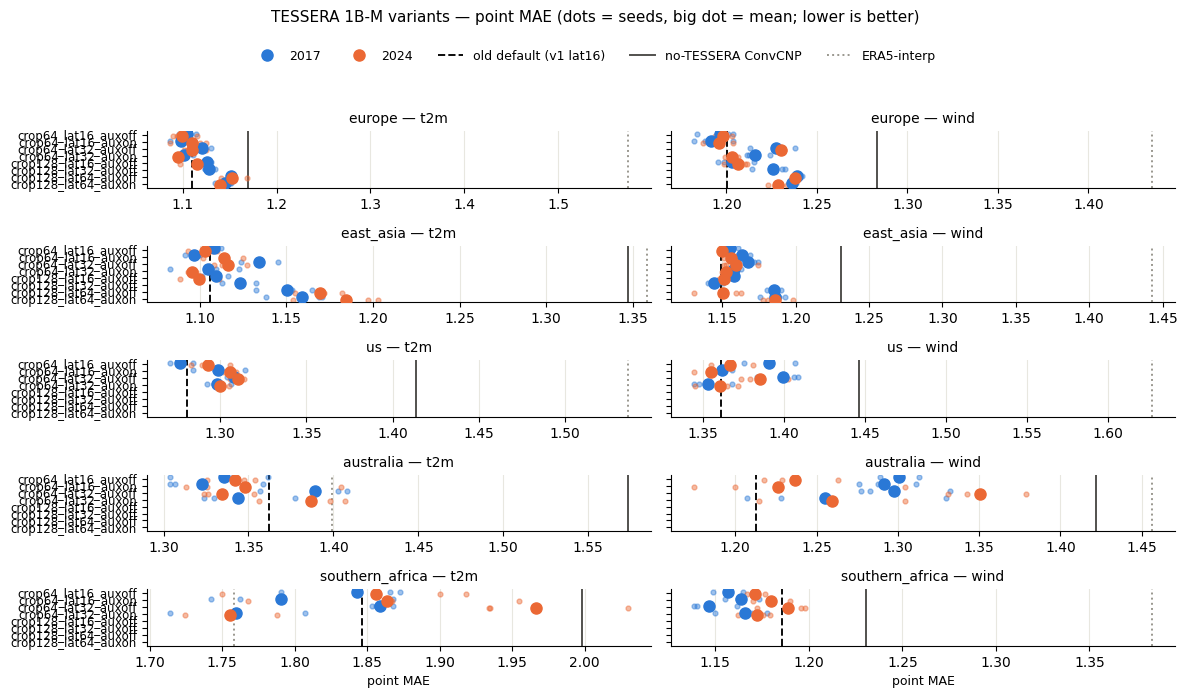

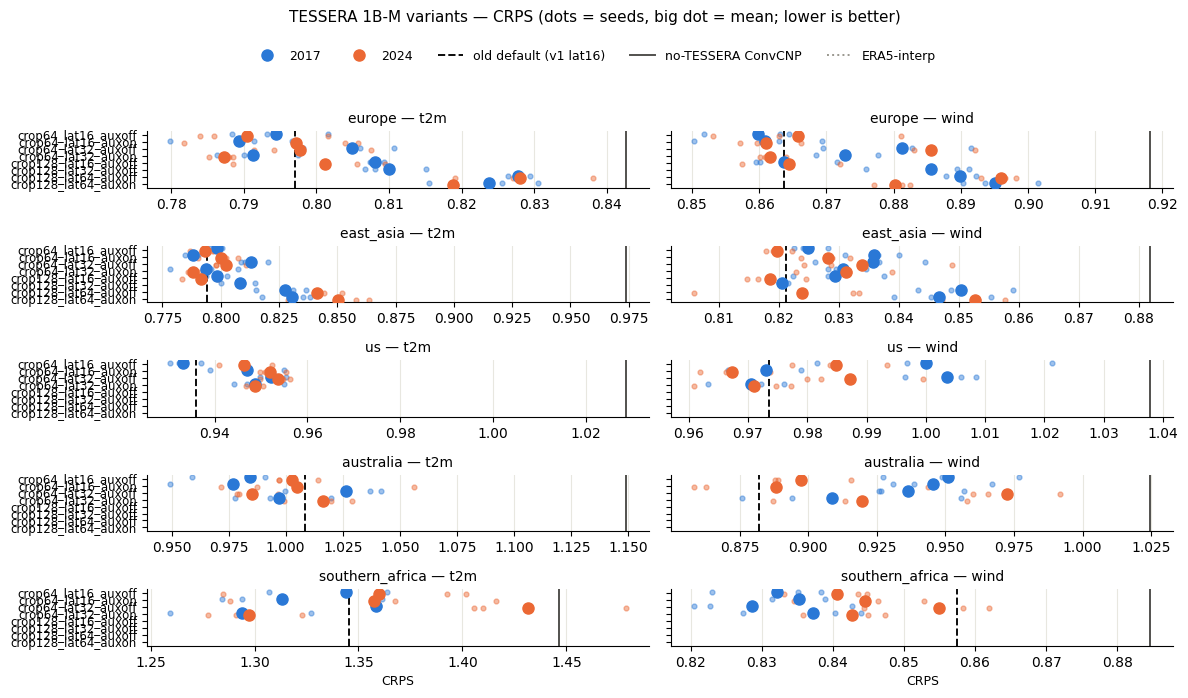

In [6]:
# ---- Dot plots: metric per variant, seeds shown, refs as lines -------------
# Identity by y-position (variant), colour only distinguishes embedding year.
# Validated palette: 2017 = blue #2a78d6, 2024 = orange #eb6834.
YEAR_COLOUR = {2017: "#2a78d6", 2024: "#eb6834"}
_REF_STYLE = {  # line style + grey ink for the reference lines
    "old default (v1 lat16)": dict(ls="--", color="#0b0b0b"),
    "no-TESSERA ConvCNP":     dict(ls="-",  color="#52514e"),
    "ERA5-interp":            dict(ls=":",  color="#9a988f"),
}

def dot_plot(metric="point_mae", label="MAE"):
    fig, axes_ = plt.subplots(len(REGIONS), len(TARGETS),
                              figsize=(12, 3 + 0.42 * len(VARIANT_ORDER)),
                              sharey=True)
    ypos = {v: i for i, v in enumerate(VARIANT_ORDER[::-1])}
    for i, region in enumerate(REGIONS):
        for j, target in enumerate(TARGETS):
            ax = axes_[i][j] if len(REGIONS) > 1 else axes_[j]
            for year in YEARS:
                dy = -0.17 if year == 2024 else 0.17
                for v in VARIANT_ORDER:
                    if df_new.empty:
                        continue
                    rows = df_new[(df_new["region"] == region) & (df_new["year"] == year)
                                  & (df_new["variant"] == v) & (df_new["target"] == target)]
                    vals = pd.to_numeric(rows.get(f"{target}_{metric}"),
                                         errors="coerce").dropna()
                    if vals.empty:
                        continue
                    y = ypos[v] + dy
                    ax.plot(vals, [y] * len(vals), "o", ms=3.5, alpha=0.45,
                            color=YEAR_COLOUR[year], zorder=2)
                    ax.plot([vals.mean()], [y], "o", ms=8,
                            color=YEAR_COLOUR[year], zorder=3,
                            label=str(year) if (v == VARIANT_ORDER[0]) else None)
            for lbl, style in _REF_STYLE.items():
                a = ref_agg(region, target, lbl)
                if a[metric] == a[metric]:
                    ax.axvline(a[metric], lw=1.4, zorder=1, **style)
            ax.set_yticks(range(len(VARIANT_ORDER)))
            ax.set_yticklabels(VARIANT_ORDER[::-1], fontsize=8.5)
            ax.set_title(f"{region} — {target}", fontsize=10)
            ax.grid(axis="x", color="#e8e7e0", lw=0.8)
            ax.set_axisbelow(True)
            for s in ("top", "right"):
                ax.spines[s].set_visible(False)
            if i == len(REGIONS) - 1:
                ax.set_xlabel(label, fontsize=9)
    handles, labels_ = (axes_[0][0] if len(REGIONS) > 1 else axes_[0]).get_legend_handles_labels()
    ref_handles = [plt.Line2D([], [], lw=1.4, **s) for s in _REF_STYLE.values()]
    fig.legend(handles + ref_handles, labels_ + list(_REF_STYLE),
               loc="upper center", bbox_to_anchor=(0.5, 1.045),
               ncol=5, frameon=False, fontsize=9)
    fig.suptitle(f"TESSERA 1B-M variants — {label} (dots = seeds, big dot = mean; "
                 f"lower is better)", y=1.09, fontsize=11)
    fig.tight_layout()
    plt.show()

dot_plot("point_mae", "point MAE")
dot_plot("crps", "CRPS")

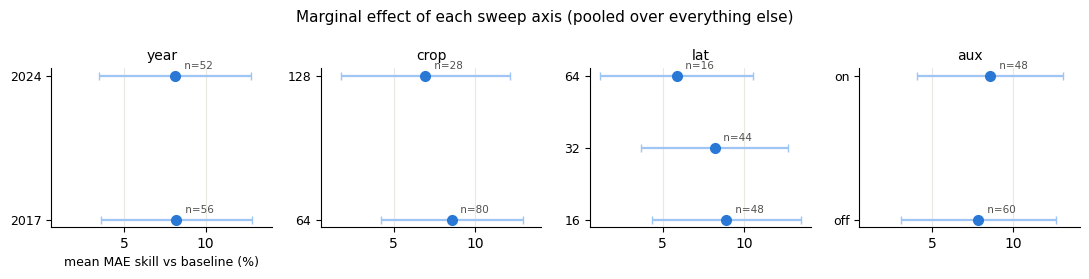

,mean,std,count
year,,,
2017,8.19,4.63,56
2024,8.12,4.68,52


In [7]:
# ---- Axis marginals: which sweep axis actually matters? --------------------
# Mean MAE-skill (vs no-TESSERA baseline) over all complete (region x target
# x variant) cells sharing each axis level. Read as: "holding everything else
# mixed, moving this axis to level X is worth ~Y % MAE". Error bar = std over
# the contributing cells (spread, not a CI).
AXES_DEF = {"year": YEARS, "crop": [64, 128], "lat": [16, 32, 64], "aux": ["off", "on"]}

def marginal_skills():
    base = {(r, t): ref_agg(r, t, "no-TESSERA ConvCNP")["point_mae"]
            for r in REGIONS for t in TARGETS}
    recs = []
    for year in YEARS:
        for v in VARIANT_ORDER:
            pv = parse_variant(f"t2m_{v}")  # crop/lat/aux from the key
            for r in REGIONS:
                for t in TARGETS:
                    mv = variant_agg(r, year, v, t)["point_mae"]
                    b = base[(r, t)]
                    if mv == mv and b == b:
                        recs.append({"year": year, "crop": pv["crop"],
                                     "lat": pv["lat"], "aux": pv["aux"],
                                     "skill": 100 * (b - mv) / b})
    return pd.DataFrame(recs)

msk = marginal_skills()
if msk.empty:
    print("No complete cells yet — marginals appear once results land.")
else:
    fig, axs = plt.subplots(1, len(AXES_DEF), figsize=(11, 2.8), sharex=True)
    for ax, (axis, levels) in zip(axs, AXES_DEF.items()):
        stats = [(lv, msk[msk[axis] == lv]["skill"]) for lv in levels]
        for k, (lv, vals) in enumerate(stats):
            if vals.empty:
                continue
            ax.errorbar(vals.mean(), k, xerr=vals.std(), fmt="o", ms=7,
                        color="#2a78d6", ecolor="#9ec5f4", capsize=3, lw=1.6)
            ax.annotate(f" n={len(vals)}", (vals.mean(), k), fontsize=7.5,
                        color="#52514e", xytext=(4, 5), textcoords="offset points")
        ax.set_yticks(range(len(levels)))
        ax.set_yticklabels([str(l) for l in levels], fontsize=9)
        ax.set_title(axis, fontsize=10)
        ax.grid(axis="x", color="#e8e7e0", lw=0.8)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    axs[0].set_xlabel("mean MAE skill vs baseline (%)", fontsize=9)
    fig.suptitle("Marginal effect of each sweep axis (pooled over everything else)",
                 fontsize=11)
    fig.tight_layout()
    plt.show()
    display(msk.groupby("year")["skill"].agg(["mean", "std", "count"]).round(2))

## Reading the results / next steps

1. **Shortlist rule of thumb**: prefer the (year, variant) with the best
   `mean_skill` **among those with `n_cells == 4`** and a `min_skill` that
   doesn't collapse in any cell — a variant that wins on average but loses to
   the old default somewhere is a risky rollout choice. Cross-check the CRPS
   ranking: a good variant should win on both point accuracy and the proper
   scoring rule.
2. **Old default as the bar**: the previous default (v1 lat16 +mTPI) row in the
   skill table is the number to beat — if no 1B-M variant clears it in both
   regions, the new embeddings don't justify a rollout yet.
3. **Marginals** tell you *which axis to spend money on* for other tessera
   variants later (e.g. if lat dim dominates and aux is a wash, future ablations
   can fix aux=off).
4. **Pending**: 2024 `crop128_lat32_auxoff` fills in automatically once its VAE
   finishes → copy the latents (see `processed/vae_tessera_1B-M/provenance.txt`)
   and re-run the two 2024 submit scripts (idempotent, +12 jobs).
5. **Rollout**: once a winner is chosen, clone the four experiment folders'
   pattern to `us` / `australia` / `southern_africa` with only the winning
   variant's entries (or reuse the full yaml and submit selectively).